## Quantum Sand Project Template Pillow 001

### Import dependencies

We will import `PIL`, `matplotlib` and `numpy`.

In [1]:
from PIL import Image
from PIL import ImageDraw
from PIL import ImageFont
from matplotlib.pyplot import imshow
import numpy as np

### Watermark an existing image and save it as a different image

Using PIL we can add a watermark to an existing image and then save it as a different image.

PIL is Pillow, a Python Imaging Library (fork). This adds image processing capabilities. From PIL we are using the following imports;

* `Image`
* `ImageDraw`
* `ImageFont`

We will set `original_image_filepath` to an existing file within the `quantumsand-project-templates-resources` directory.

We will choose the output image filepath within `watermarked_image_filepath` and set it to `"pillow_watermark.jpg"`.

We can build a `watermark_text_string` using string interpolation from both `date_string` and `license_string`.

We are referring to the date (`date_string`) and the license (`license_string`) of the provided image.

The two colours for the text are `white_rgb` and `deepskyblue_rgb`.

We can set the `text_position_coordinates` to place the text on the existing image.

We will load a truetype font from the local filesystem using `truetype_font_filepath`.

Using `truetype()` within `ImageFont` with the following arguments;

* `font` is a filename or file-like object containing a TrueType font, `truetype_font_filepath`.
* `size` is the requested size, in pixels, 50.

We can now use this `truetype_font`.

Using the `with` statement in Python; `with Image.open(original_image_filepath, 'r') as im:` we can now work with this original image. Python will simplify the resource management ensuring that the original image file is closed safely after this block of code has run.

Using `ImageDraw.Draw(im)` we can create an object `draw` that can be used to draw in the given image.

Using `text()` within PIL we can provide the following arguments;

* `xy`, the anchor coordinates of the text, `text_position_coordinates`.
* `text`, the string to be drawn, `watermark_text_string`.
* `font`, an `ImageFont` instance, `truetype_font`.
* `fill`, the colour to use for the text, `white_rgb`.
* `stroke_width`, the width of the text stroke, 2.
* `stroke_fill`, the colour to use for the text stroke, `deepskyblue_rgb`.

Using `Image.save()` within PIL with the argument;

* `fp`, which is just a filename string, `watermarked_image_filepath`.

Is sufficient for writing out `"pillow_watermark.jpg"`, which is already available in the `quantumsand-project-templates-resources` directory.

In [2]:
original_image_filepath = "../quantumsand-project-templates-resources/yolo_object_detection_results_0.jpg"
watermarked_image_filepath = "../quantumsand-project-templates-resources/pillow_watermark.jpg"

date_string = "20240905"
license_string = "CC BY-SA 4.0"
watermark_text_string = f"Watermark; {date_string} {license_string}"

white_rgb = (255, 255, 255)
deepskyblue_rgb = (0, 191, 255)

text_position_coordinates = (50, 880)
truetype_font_filepath = "../quantumsand-project-templates-resources/Nunito-Regular.ttf"

truetype_font = ImageFont.truetype(truetype_font_filepath, 50)

with Image.open(original_image_filepath, 'r') as im:
    draw = ImageDraw.Draw(im)
    
    draw.text(text_position_coordinates, 
              watermark_text_string, 
              font=truetype_font,
              fill=white_rgb,
              stroke_width=2, 
              stroke_fill=deepskyblue_rgb)

    im.save(watermarked_image_filepath)

We can load the generated `"pillow_watermark.jpg"` defined in `watermarked_image_filepath` into `watermarked_image`.

To display the generated watermarked image we can use PIL `open()` to open and identify the given image file. We will pass in the argument;
* `fp` which is just a filename string, `watermarked_image_filepath`.

We will also convert the `watermarked_image` into a `numpy_array`. In this scenario you do not need to create a NumPy array, but it can be useful to have the image data available as a `numpy_array` for other reasons.

Using `asarray()` within NumPy with the provided `watermarked_image` provides the `numpy_array`.

Finally, we can use `imshow()` within Matplotlib to render the `numpy_array` obtained from the resulting jpeg image.

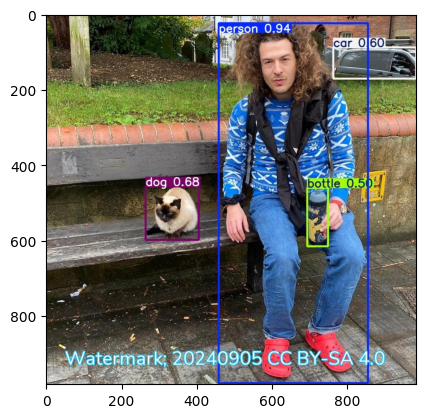

In [3]:
watermarked_image = Image.open(watermarked_image_filepath, 'r')
numpy_array = np.asarray(watermarked_image)
imshow(numpy_array)

You can see the watermarked image with the text that was provided.

More to follow...